# Backtrader Indicator Verification

In [3]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot
from pandas import read_csv
from datetime import datetime

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.plots import curve, comparison
from lib.data import stats, ou
from lib.utils import extract_date_range, read_backtrader_data
from lib.db import BacktestDb

# Config Plot Style
pyplot.style.use(config.glyfish_style)

In [43]:
def zscore_plot(zscore, zdate, window):
    title = f'USD.CAD Exchange Rate Z-Score: $t_{{1/2}} = {window:.0f}$ days'
    curve(zscore, zdate, title=title, xlabel=f"Day", ylabel="Z-Score", lw=1)

def zscore_indicator_plot(zscore, zdate, window):
    title = f'USD.CAD Exchange Rate Z-Score Indicator: $t_{{1/2}} = {window:.0f}$ days'
    curve(zscore, zdate, title=title, xlabel=f"Day", ylabel="Z-Score", lw=1)

def zscore_trading_plot(zscore, zdate, window):
    title = f'USD.CAD Exchange Rate Z-Score from Trading: $t_{{1/2}} = {window:.0f}$ days'
    curve(zscore, zdate, title=title, xlabel=f"Day", ylabel="Z-Score", lw=1)

def exchange_rate_plot(data, date):
    title = 'USD.CAD Exchange Rate'
    mean = numpy.full(len(data), numpy.mean(data))
    comparison([data, mean], date, title=title, xlabel="Date", ylabel="USD.CAD", labels=['USD.CAD', 'Mean'], lw=1)
    
def compute_mean_reversion_halflife(data):
    mean = numpy.full(len(data), numpy.mean(data))
    xt = data - mean
    result, result_model = ou.compute_mean_half_life_estimate(xt)
    return int(result_model.param_transforms[0].param.est), result

db = BacktestDb()
backtest_id = 'C4fw3J5ztPey'
file_root = '../../../data/algorithmic_trading'

In [44]:
usd_cad_data = db.fetch_price_series("CAD=X", start_date='2007-07-22', end_date='2012-03-28')
usd_cad_data.head()

,ticker,date,open_price,high_price,low_price,close_price,adj_close_price,volume
0,CAD=X,2007-07-23,1.0479,1.04790,1.0424,1.04676,1.04676,0.0
1,CAD=X,2007-07-24,1.0466,1.04726,1.0340,1.03660,1.03660,0.0
2,CAD=X,2007-07-25,1.0366,1.04455,1.0342,1.04180,1.04180,0.0
3,CAD=X,2007-07-26,1.0418,1.05680,1.0403,1.05360,1.05360,0.0
4,CAD=X,2007-07-27,1.0536,1.06530,1.0501,1.06390,1.06390,0.0


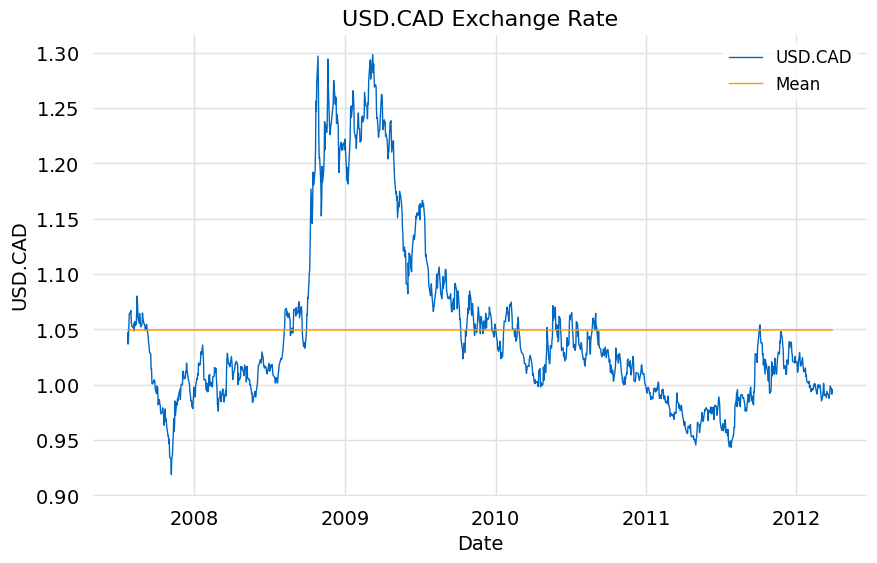

In [45]:
usd_cad_close = usd_cad_data['close_price'].to_numpy()
usd_cad_date = usd_cad_data['date'].to_numpy()
exchange_rate_plot(usd_cad_close, usd_cad_date)

## Mean Reversion Half-Life

The normalized deviation of the price, Z-Score, is defined by

$
\begin{align}
Z = \frac{y - \text{moving\_avg}(y, \text{halflife})}{\text{moving\_std}(y, \text{halflife})}
\end{align}
\tag{1}
$

where $\text{halflife}$ is the estimated mean reversion halflife of the time series. Two versions of the of a trading strategy using the Z-score will be investigated. For both strategies if $\text{Z-score} \gt 0$ a multiple of Z-score shares will be held. In the first tested strategy if $\text{Z-score} \lt 0$ all held shares will be sold and no purchases will be made until $\text{Z-score} \gt 0$. In the second version of the strategy the behavior for $\text{Z-score} \gt 0$ will be the same but if $\text{Z-score} \lt 0$ a short position consisting of a multiple of $-\text{Z-score}$ will be held.

### Mean Reversion Halflife

In [32]:
mean_reversion_half_life, result = compute_mean_reversion_halflife(usd_cad_close)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     3.294
Date:                Sun, 31 Mar 2024   Prob (F-statistic):             0.0698
Time:                        16:51:42   Log-Likelihood:                 4061.0
No. Observations:                1215   AIC:                            -8118.
Df Residuals:                    1213   BIC:                            -8108.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.194e-05      0.000     -0.171      0.864      -0.001       0.000
x1            -0.0056      0.003     -1.815      0.070      -0.012       0.000
==============================================================================
Omnibus:                      113.526   Durbin-Watson:                   1.979
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              434.957
Skew:                           0.380   Prob(JB):                     3.55e-95
Kurtosis:                       5.831   Cond. No.                         12.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

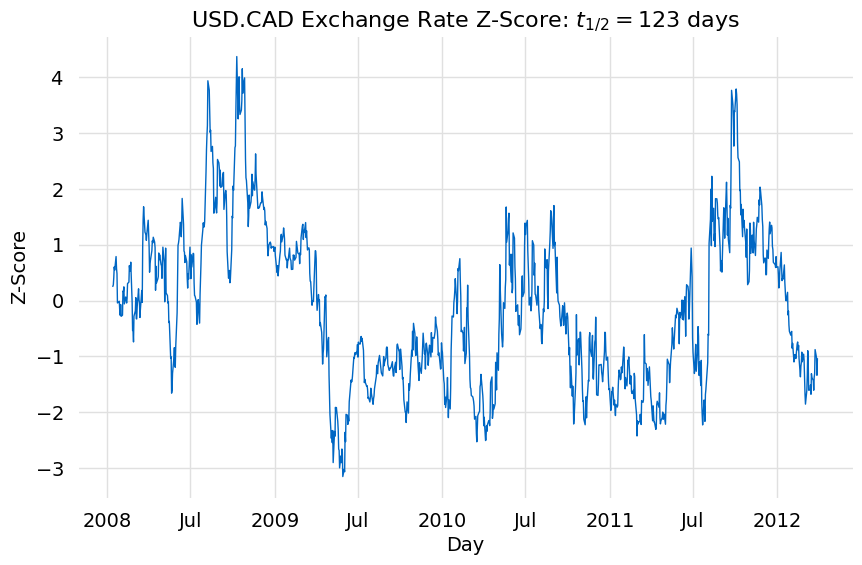

In [46]:
zdate, zscore = stats.compute_zscore(usd_cad_date, usd_cad_close, mean_reversion_half_life)
zscore_plot(zscore, zdate, mean_reversion_half_life)

## Z-Score Indicator Verification

In [47]:
df = db.fetch_zscore_indicator(backtest_id)
df.head()

,date,run_id,indicator,ensemble_id,ticker,zscore,half_life
0,2008-01-15,C4fw3J5ztPey,zscore,None,CAD=X,0.328399,124
1,2008-01-16,C4fw3J5ztPey,zscore,None,CAD=X,0.336484,124
2,2008-01-17,C4fw3J5ztPey,zscore,None,CAD=X,0.608822,124
3,2008-01-18,C4fw3J5ztPey,zscore,None,CAD=X,0.611988,124
4,2008-01-21,C4fw3J5ztPey,zscore,None,CAD=X,0.886193,124


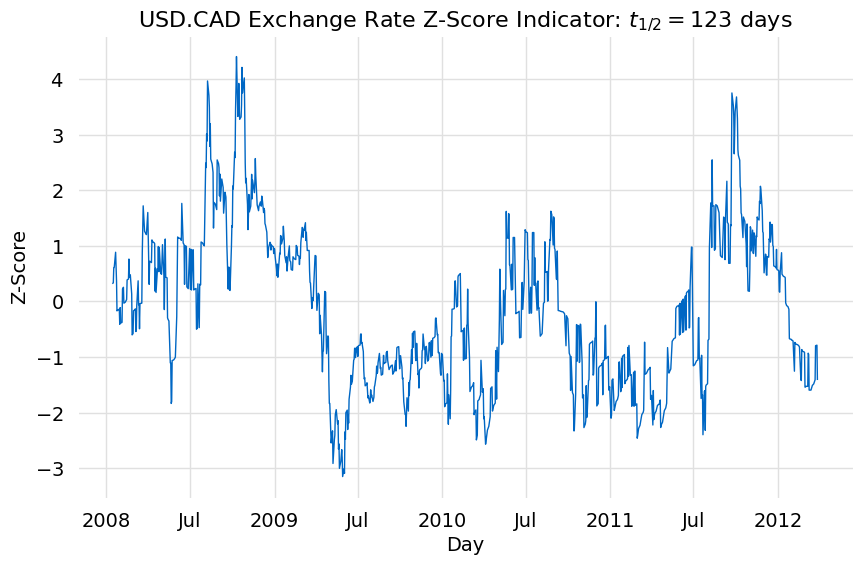

In [49]:
zscore = df.zscore.to_numpy()
zdate = df.date.to_numpy()
zscore_indicator_plot(zscore, zdate, mean_reversion_half_life)